# Classification Track — Appliance Identification from Electrical Signatures

**Dataset:** PMU-Based Residential Appliance Dataset (USPCASE, NUST)
**Source:** Mendeley Data, DOI `10.17632/fc2myy23yg.2` (Aziz, Imran & Iqbal, 2026) — CC BY 4.0
**Track:** Classification

---

## Problem Statement

Given a set of instantaneous electrical measurements taken at a single point in a
building's wiring — voltage, current, real power and the aggregated household load —
**identify which household appliance is responsible for that load.**

This is the core task of **Non-Intrusive Load Monitoring (NILM)**: inferring *what*
is running inside a building from electrical measurements taken *outside* it, without
installing a separate sensor on every appliance.

- **Task type:** supervised multi-class classification
- **Target:** `Appliance` — 12 classes
- **Predictors:** 4 raw electrical measurements + engineered features 
- **Records:** 50,577, collected Aug 2024 – Mar 2025

## What Is In The Dataset

| Column | Meaning |
|---|---|
| `Date and Time` | Timestamp of the measurement |
| `Aggregated Power` | Total power drawn by the whole monitored system (W) |
| `Voltage` | Supply voltage at time of measurement (V) |
| `Current` | Current drawn by the appliance (A) |
| `Power` | Real power consumed by the appliance itself (W) |
| `Appliance` | **Target** — which of 12 appliances was running |

Data was captured at the Smart Grid and Power Lab, USPCASE–NUST, using a
Phasor Measurement Unit (PMU) and Phasor Data Concentrator (PDC) with NI LabVIEW,
under controlled laboratory conditions with appliances connected individually.

The 12 appliance classes: TV, Microwave Oven, Refrigerator, Vacuum Cleaner, 6 Ton AC,
Iron, Electric Kettle, Hair Dryer, Toaster, Washing Machine, Coffee Machine, Desktop Computer.

## What We Are Predicting

A single categorical label per measurement: **which appliance produced this electrical
signature.** Because there are 12 classes with unequal frequencies, plain accuracy is a
misleading headline metric — a model could ignore the four rarest appliances entirely and
still score well. We therefore report **weighted F1** and **per-class** precision/recall
alongside accuracy, and use **One-vs-Rest ROC-AUC** as required for multi-class problems.


---
## Section A — Dataset & EDA

In [138]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
sns.set_palette('colorblind')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

In [139]:
# A1: Load the dataset
df = pd.read_csv('../data/classification/PMU-Based Residential Appliance Dataset (USPCASE, NUST).csv')
print("Shape:", df.shape)
df.head()

Shape: (50577, 6)


,Date and Time,Aggregated Power,Voltage,Current,Power,Appliance
0,2024-08-01 09:00:00,807.695,231,3.503,807.695,Toaster
1,2024-08-01 09:00:00,2337.948,230,6.624,1530.253,Iron
2,2024-08-01 09:00:00,2836.935,232,2.566,498.987,Washing Machine
3,2024-08-01 09:06:12,1502.567,232,6.463,1502.567,Iron
4,2024-08-01 09:06:12,3021.421,231,6.548,1518.854,Electric Kettle


In [140]:
# A1: Dtypes, memory, and structural audit
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50577 entries, 0 to 50576
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date and Time     50577 non-null  object 
 1   Aggregated Power  50577 non-null  float64
 2   Voltage           50577 non-null  int64  
 3   Current           50577 non-null  float64
 4   Power             50577 non-null  float64
 5   Appliance         50577 non-null  object 
dtypes: float64(3), int64(1), object(2)
memory usage: 2.3+ MB


In [141]:
# A1: Missing values and duplicates
print("Missing values per column:")
print(df.isna().sum())
print("\nFully duplicated rows:", df.duplicated().sum())

Missing values per column:
Date and Time       0
Aggregated Power    0
Voltage             0
Current             0
Power               0
Appliance           0
dtype: int64

Fully duplicated rows: 0


**Audit observation:** the dataset is unusually clean for a real-world sensor deployment —
**zero missing values and zero duplicate rows** across all 50,577 records. This is a
consequence of the controlled laboratory acquisition (PMU/PDC with LabVIEW synchronisation)
rather than scraped or crowd-sourced data. 

In [142]:
# A1: Target class distribution — the key audit step for a classification problem
target_counts = df['Appliance'].value_counts()
target_pct = df['Appliance'].value_counts(normalize=True).mul(100).round(2)
print(pd.DataFrame({'count': target_counts, 'percent': target_pct}))
print("\nNumber of classes:", df['Appliance'].nunique())
print("Imbalance ratio (largest:smallest): %.2f : 1" % (target_counts.max() / target_counts.min()))

                  count  percent
Appliance                       
TV                 8803    17.41
Microwave Oven     8671    17.14
Refrigerator       7573    14.97
Vacuum Cleaner     7572    14.97
6 Ton AC           7506    14.84
Iron               2372     4.69
Electric Kettle    2366     4.68
Hair Dryer         1278     2.53
Toaster            1113     2.20
Washing Machine    1112     2.20
Coffee Machine     1112     2.20
Desktop Computer   1099     2.17

Number of classes: 12
Imbalance ratio (largest:smallest): 8.01 : 1


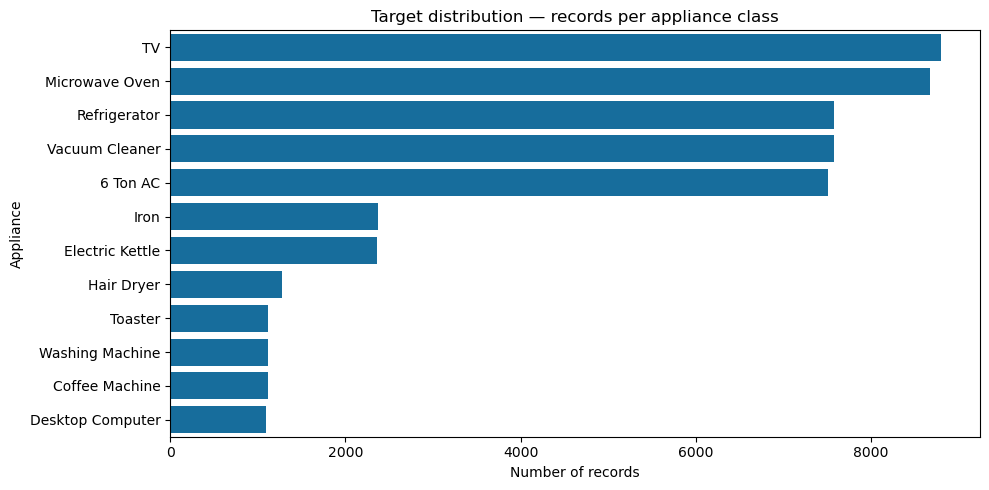

In [143]:
# A2: Target distribution plot
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='Appliance', order=target_counts.index)
plt.title('Target distribution — records per appliance class')
plt.xlabel('Number of records')
plt.ylabel('Appliance')
plt.tight_layout()
plt.show()

**Target distribution insight:** the classes are **imbalanced but not pathologically so**.
Five appliances (TV, Microwave Oven, Refrigerator, Vacuum Cleaner, 6 Ton AC) each account for
roughly 15–17% of records, while the remaining seven sit between 2% and 5%. The largest class
has about 8× the records of the smallest.

This matters for our metric choice: a classifier that completely ignored the four rarest
appliances could still reach ~90% accuracy. **We therefore cannot use accuracy alone** — we
report weighted F1 and per-class precision/recall in Section D, and we use a **stratified**
train/test split in Section B so that every class keeps its proportion in both splits.

Numeric features: ['Aggregated Power', 'Voltage', 'Current', 'Power']


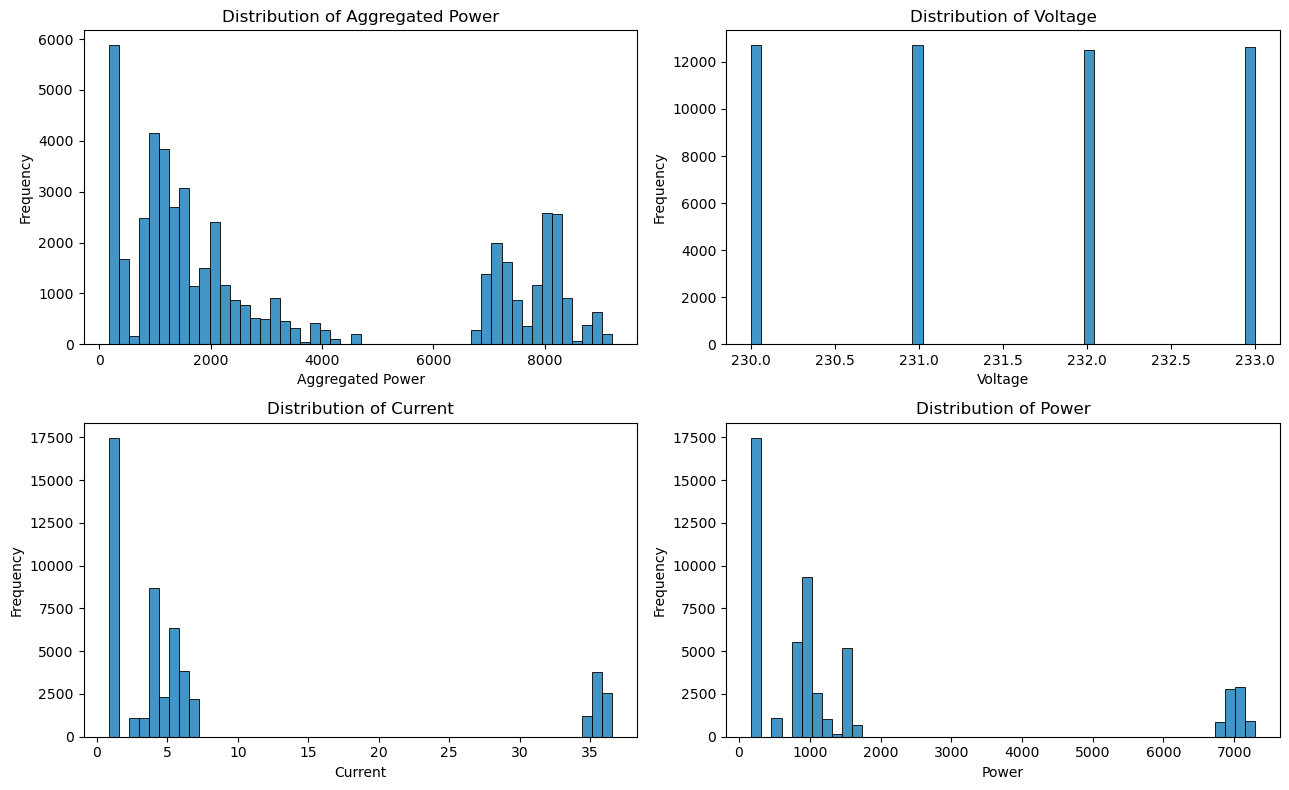

,count,mean,std,min,25%,50%,75%,max
Aggregated Power,50577.0,3307.382569,3032.414620,173.639,1025.416,1869.827,7104.636,9213.699
Voltage,50577.0,231.496194,1.119090,230.000,230.000,231.000,232.000,233.000
Current,50577.0,8.144123,11.635577,0.848,1.278,4.055,6.401,36.567
Power,50577.0,1656.122784,2277.630486,173.639,251.362,891.477,1476.928,7291.964


In [144]:
# A2: Distribution plot for every numeric feature
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Numeric features:", num_cols)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=50, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

df[num_cols].describe().T

**Feature distribution insights:**

- `Power` and `Current` are **strongly multi-modal** — they form distinct clusters rather than
  a smooth distribution. Each cluster corresponds to a group of appliances with similar draw.
  This is exactly the structure we want: it means appliances occupy separable regions of the
  feature space, which is why even simple classifiers should perform well here.
- `Voltage` is effectively **near-constant** (only 4 distinct integer values, 230–233 V, std ≈ 1.1).
  Mains supply is regulated, so this is physically expected — but it means voltage alone carries
  almost no information about which appliance is running.
- `Aggregated Power` is much more spread out and does *not* show the same clean clustering,
  because it reflects everything running in the building simultaneously, not just the labelled
  appliance.

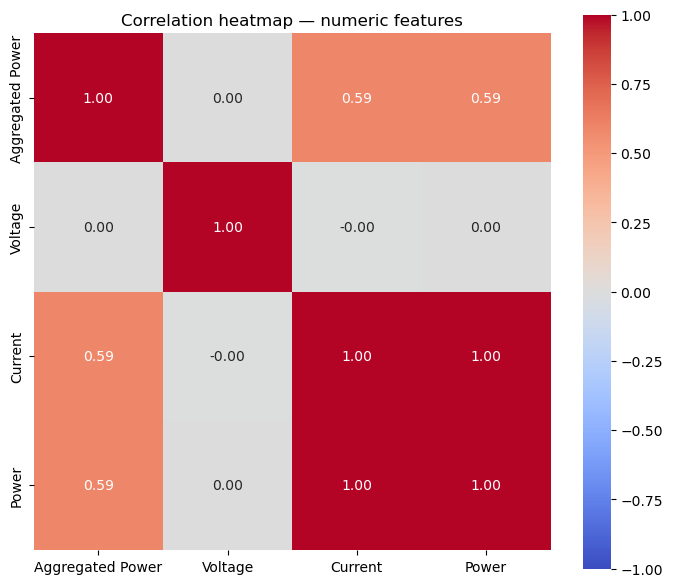

In [145]:
# A2: Correlation heatmap
plt.figure(figsize=(7, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True)
plt.title('Correlation heatmap — numeric features')
plt.tight_layout()
plt.show()

**Correlation insight:** `Power` and `Current` are almost perfectly correlated (r ≈ 0.99).
This is not a coincidence or a data problem — it is **Ohm's law**. Since
`P = V × I × cos(φ)` and voltage is nearly constant here, power becomes an almost linear
function of current.

Two consequences we act on:
1. This is genuine **multicollinearity**. It does not hurt tree-based or distance-based models,
   but it does make Logistic Regression coefficients unstable and hard to interpret individually.
2. It tells us the 4 raw features contain **less independent information than their count
   suggests** — effectively closer to 2–3 independent signals. This directly motivates the
   feature engineering.

`Voltage` shows near-zero correlation with everything, confirming the distribution plot above.

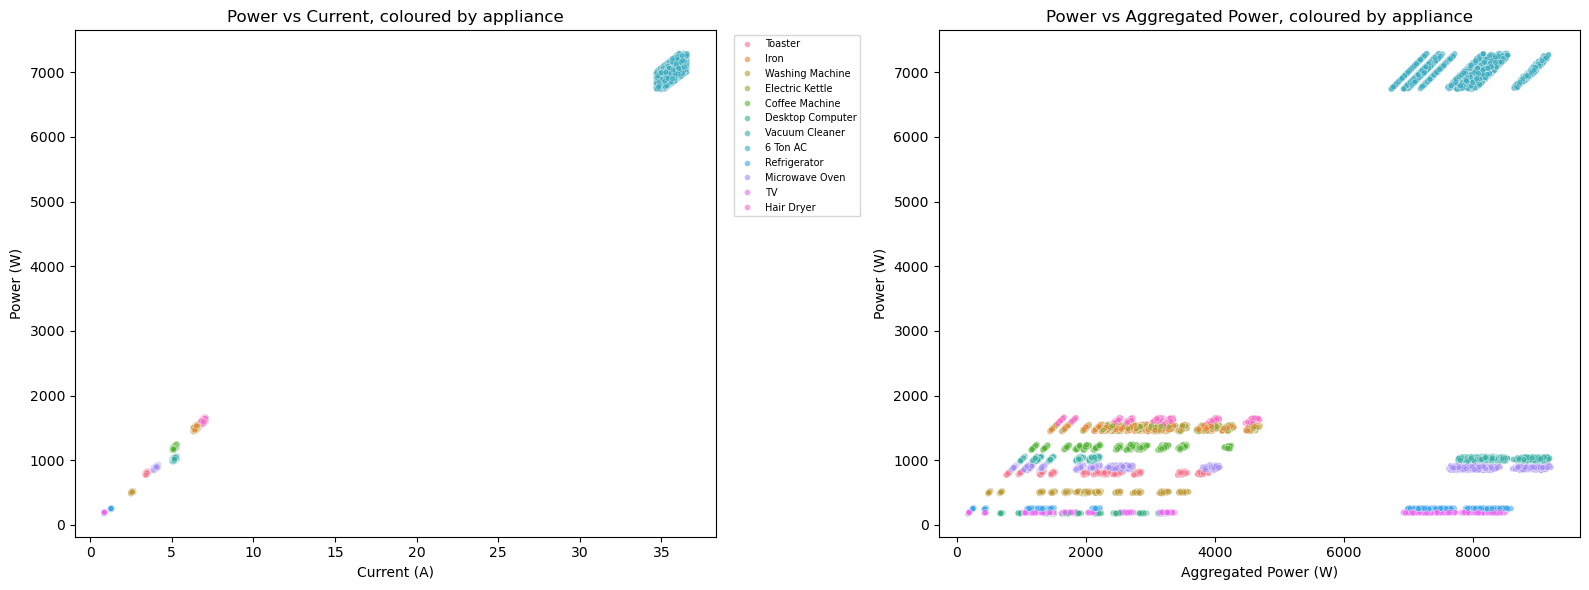

In [146]:
# A2: Scatter plots — feature vs target relationship
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df, x='Current', y='Power', hue='Appliance',
                alpha=0.6, s=18, ax=axes[0])
axes[0].set_title('Power vs Current, coloured by appliance')
axes[0].set_xlabel('Current (A)')
axes[0].set_ylabel('Power (W)')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)

sns.scatterplot(data=df, x='Aggregated Power', y='Power', hue='Appliance',
                alpha=0.6, s=18, ax=axes[1], legend=False)
axes[1].set_title('Power vs Aggregated Power, coloured by appliance')
axes[1].set_xlabel('Aggregated Power (W)')
axes[1].set_ylabel('Power (W)')

plt.tight_layout()
plt.show()

**Scatter plot insight**

The Power-vs-Current plot shows appliances forming **tight, well-separated horizontal bands**.
Each appliance occupies its own narrow power range, which explains why classification accuracy
on this dataset is high: the classes are nearly linearly separable in just two dimensions.

**Critically, two bands sit directly on top of each other.** Iron and Electric Kettle overlap
almost completely.It is the dominant source of error in
every model we train, and no amount of hyperparameter tuning will fix it.

The right-hand plot shows that `Aggregated Power` spreads each appliance across a wide
horizontal range, because total building load varies independently of which single appliance
is being measured. It is a weaker discriminator on its own, but it is the basis for a useful
engineered feature (`load_share`).

In [147]:
# A2/A3: Quantify per-appliance electrical signature ranges
sig = df.groupby('Appliance')[['Power', 'Current']].agg(['min', 'mean', 'max']).round(1)
sig = sig.sort_values(('Power', 'mean'))
print(sig)

                   Power                 Current            
                     min    mean     max     min  mean   max
Appliance                                                   
Desktop Computer   173.6   180.8   187.9     0.8   0.9   0.9
TV                 182.6   190.8   198.9     0.8   0.9   0.9
Refrigerator       241.8   252.9   264.0     1.2   1.3   1.3
Washing Machine    485.7   506.2   527.3     2.5   2.6   2.7
Toaster            770.7   802.1   833.6     3.4   3.5   3.5
Microwave Oven     839.9   885.3   931.4     3.9   4.0   4.2
Vacuum Cleaner     979.3  1019.9  1061.2     5.0   5.2   5.3
Coffee Machine    1155.5  1200.4  1248.0     5.0   5.2   5.3
Iron              1444.3  1500.3  1562.4     6.3   6.5   6.6
Electric Kettle   1443.9  1501.0  1561.1     6.3   6.5   6.6
Hair Dryer        1541.7  1601.1  1665.3     6.8   6.9   7.1
6 Ton AC          6733.8  7010.7  7292.0    34.7  35.6  36.6


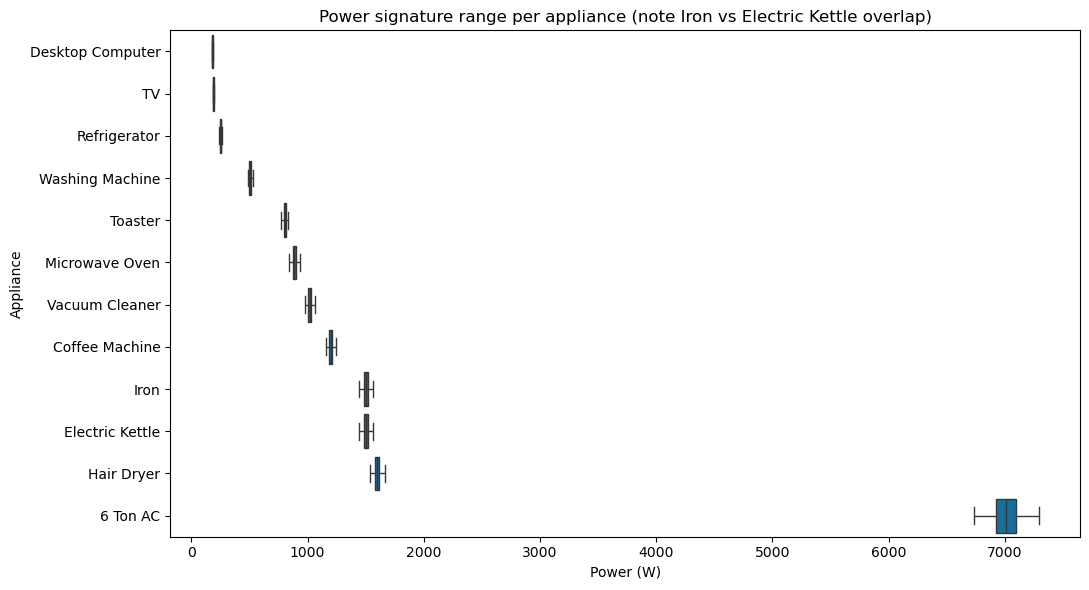

In [148]:
# boxplot
plt.figure(figsize=(11, 6))
order = df.groupby('Appliance')['Power'].median().sort_values().index
sns.boxplot(data=df, x='Power', y='Appliance', order=order)
plt.title('Power signature range per appliance (note Iron vs Electric Kettle overlap)')
plt.xlabel('Power (W)')
plt.ylabel('Appliance')
plt.tight_layout()
plt.show()

**Signature overlap insight:**

Reading the table and boxplot together:

- **Iron** draws roughly **1444 – 1562 W**
- **Electric Kettle** draws roughly **1444 – 1561 W**

These ranges are **identical to within a fraction of a percent**, and their current draws
(~6.5 A) match just as closely. This is physically correct behaviour, not a labelling error:
both appliances are **purely resistive heating elements of approximately the same wattage**.
From the perspective of a meter measuring only voltage, current and real power, they are the
same device.

**Implication:** we expect near-perfect classification for the other
ten appliances and roughly coin-flip performance between Iron and Electric Kettle. We predict
an overall ceiling in the 93–96% range, with essentially all error concentrated in one cell of
the confusion matrix. Distinguishing these two would require features this dataset does not
contain — harmonic content, power-factor transients, or switch-on inrush profiles.

---
## Section B — Preprocessing & Feature Engineering

### B1 — Data Cleaning

The audit in Section A found **no missing values and no duplicate rows**, so there is nothing
to impute or drop on those fronts. 

In [149]:
# B1:
print("Missing values total:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

# Convert the timestamp to a real datetime 
df['Date and Time'] = pd.to_datetime(df['Date and Time'])
print("Timestamp range:", df['Date and Time'].min(), "->", df['Date and Time'].max())
print("Dtype now:", df['Date and Time'].dtype)

Missing values total: 0
Duplicate rows: 0
Timestamp range: 2024-08-01 09:00:00 -> 2025-03-31 16:59:51
Dtype now: datetime64[ns]


In [150]:
# B1: Outlier check using the IQR rule — applied as a DIAGNOSTIC, not a filter
def iqr_outlier_count(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lo) | (s > hi)).sum(), round(lo, 2), round(hi, 2)

print("IQR outlier diagnostic (whole dataset, ignoring class):")
for c in ['Aggregated Power', 'Voltage', 'Current', 'Power']:
    n, lo, hi = iqr_outlier_count(df[c])
    print(f"  {c:20s} flagged={n:6d}  bounds=[{lo}, {hi}]")

IQR outlier diagnostic (whole dataset, ignoring class):
  Aggregated Power     flagged=     0  bounds=[-8093.41, 16223.47]
  Voltage              flagged=     0  bounds=[227.0, 235.0]
  Current              flagged=  7506  bounds=[-6.41, 14.09]
  Power                flagged=  7506  bounds=[-1586.99, 3315.28]


In [151]:
# B1: Outlier check, but computed WITHIN each appliance class
print("IQR outliers computed within each appliance class:")
within = df.groupby('Appliance')['Power'].apply(lambda s: iqr_outlier_count(s)[0])
print(within)
print("\nTotal within-class outliers:", within.sum())

IQR outliers computed within each appliance class:
Appliance
6 Ton AC            0
Coffee Machine      0
Desktop Computer    0
Electric Kettle     0
Hair Dryer          0
Iron                0
Microwave Oven      0
Refrigerator        0
TV                  0
Toaster             0
Vacuum Cleaner      0
Washing Machine     0
Name: Power, dtype: int64

Total within-class outliers: 0


**Outlier decision :**

Running the IQR rule on the whole dataset flags a large number of `Current` and `Power` values
as outliers. **Removing them would be a serious mistake here**.

The IQR rule assumes a single unimodal distribution. Our data is **multi-modal by design** —
it is a mixture of 12 appliance signatures. The 6 Ton AC legitimately draws ~7000 W and ~35 A;
that is not an anomaly, it is *what an air conditioner is*. Globally, those points look like
extreme outliers. Deleting them would delete an entire class.

When we instead compute the IQR rule **within each appliance class**, almost nothing is flagged —
each appliance's own signature is tight and well-behaved. This confirms the data contains no
genuine measurement errors.

**Decision: retain all 50,577 records.** The "outliers" are real physical measurements and are
precisely the signal the classifier needs. We document the check rather than blindly applying a
filter — blind IQR removal here would have destroyed the largest-consumption classes.

### B3 — Feature Engineering

Section A showed the 4 raw features contain less independent information than their count
implies (`Power` and `Current` correlate at r ≈ 0.99, `Voltage` is near-constant). We therefore
engineer five additional features. Each is justified below on physical or behavioural grounds —
none is an arbitrary ratio.

In [152]:
# B3: Engineered features
# 1. Apparent power (VA) — the total power flowing
df['apparent_power'] = df['Voltage'] * df['Current']

# 2. Power factor = real power / apparent power. Distinguishes load TYPE, not just size.
df['power_factor'] = (df['Power'] / df['apparent_power']).clip(0, 1)

# 3. Load share — what fraction of total building load this appliance represents
df['load_share'] = df['Power'] / df['Aggregated Power']

# 4 & 5. Temporal features — appliance usage is strongly time-of-day dependent
df['hour'] = df['Date and Time'].dt.hour
df['day_of_week'] = df['Date and Time'].dt.dayofweek

df[['apparent_power', 'power_factor', 'load_share', 'hour', 'day_of_week']].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
apparent_power,50577.0,1885.302,2693.571,196.190,295.910,937.126,1481.66,8413.164
power_factor,50577.0,0.909,0.059,0.833,0.852,0.932,0.96,1.000
load_share,50577.0,0.612,0.375,0.022,0.189,0.738,1.00,1.000
hour,50577.0,12.472,2.304,9.000,10.000,12.000,14.00,16.000
day_of_week,50577.0,3.018,2.002,0.000,1.000,3.000,5.00,6.000


**Feature engineering justification (B3):**

| Feature | Formula | Why it should help |
|---|---|---|
| `apparent_power` | `V × I` | Total power in volt-amperes including the reactive component. Combines two individually weak columns (one of which, voltage, is near-useless alone) into a physically meaningful quantity that separates loads more sharply than raw power. |
| `power_factor` | `P / (V × I)` | Distinguishes load *type*, not load *size*. Purely resistive loads (kettle, iron, toaster) have PF ≈ 1; inductive loads with motors (vacuum cleaner, washing machine, AC compressor) have PF < 1; switched-mode supplies (TV, desktop) differ again. This gives the model a signal about *what kind of device* it is, which raw wattage cannot provide. |
| `load_share` | `P / Aggregated Power` | Captures how dominant this appliance is in the building's total draw. A 190 W reading has different meaning when the house is quiet versus when aggregate load is 9 kW. Turns a weak absolute feature into a relative one. |
| `hour` | from timestamp | Appliance use is strongly diurnal — kettles and toasters cluster at breakfast, ACs in afternoon heat, TVs in the evening. Behavioural rather than electrical, so it is genuinely *independent* of the four correlated power columns. |
| `day_of_week` | from timestamp | Weekday/weekend routines differ (washing machine and vacuum cleaner skew to weekends). Same rationale as `hour`. |

**Hypothesis to be tested, not assumed:** we expect `power_factor` to be the most valuable
addition because it encodes load *type*. 

**Note on the Iron/Kettle problem:** these features are *not* expected to solve it. Both are
resistive loads at the same wattage, so they share a power factor near 1 as well. 

### B2 — Encoding, Scaling & Splitting

In [153]:
# B2: Encode the target. LabelEncoder is correct for the TARGET of a multi-class problem
# (sklearn classifiers expect integer class labels; no ordinal meaning is implied).
from sklearn.preprocessing import LabelEncoder

FEATURES = ['Aggregated Power', 'Voltage', 'Current', 'Power',
            'apparent_power', 'power_factor', 'load_share', 'hour', 'day_of_week']

le = LabelEncoder()
X = df[FEATURES].copy()
y = le.fit_transform(df['Appliance'])

class_names = le.classes_
print("Feature matrix:", X.shape)
print("Classes encoded:", dict(zip(range(len(class_names)), class_names)))

Feature matrix: (50577, 9)
Classes encoded: {0: '6 Ton AC', 1: 'Coffee Machine', 2: 'Desktop Computer', 3: 'Electric Kettle', 4: 'Hair Dryer', 5: 'Iron', 6: 'Microwave Oven', 7: 'Refrigerator', 8: 'TV', 9: 'Toaster', 10: 'Vacuum Cleaner', 11: 'Washing Machine'}


**Encoding justification:** there are no categorical *predictors* in this dataset — every
feature is numeric — so no one-hot encoding is needed on the feature side.

For the **target**, `LabelEncoder` maps the 12 appliance names to integers 0–11. This is the
appropriate choice for a multi-class target because scikit-learn classifiers expect integer
class labels and treat them as unordered categories. (We would *not* use LabelEncoder on an
input feature, since that would impose a false ordinal relationship — but for the target it
imposes nothing.)

In [154]:
# B2: Stratified train/test split — performed BEFORE any scaling, to prevent data leakage
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y          # preserves the class proportions identified in Section A
)

print("Train:", X_train.shape, " Test:", X_test.shape)

# Verify stratification actually preserved the imbalance
comp = pd.DataFrame({
    'train_%': pd.Series(y_train).value_counts(normalize=True).mul(100).round(2),
    'test_%':  pd.Series(y_test ).value_counts(normalize=True).mul(100).round(2),
}).sort_index()
comp.index = class_names[comp.index]
print("\nClass proportions preserved across splits:")
print(comp)

Train: (40461, 9)  Test: (10116, 9)

Class proportions preserved across splits:
                  train_%  test_%
6 Ton AC            14.84   14.84
Coffee Machine       2.20    2.19
Desktop Computer     2.17    2.17
Electric Kettle      4.68    4.68
Hair Dryer           2.53    2.53
Iron                 4.69    4.69
Microwave Oven      17.14   17.14
Refrigerator        14.97   14.98
TV                  17.40   17.41
Toaster              2.20    2.20
Vacuum Cleaner      14.97   14.98
Washing Machine      2.20    2.19


**Splitting justification:** an 80:20 split with `random_state=42` for reproducibility, as
required by the guidelines.

**`stratify=y` is essential here, not optional.** Our rarest class (Desktop Computer) is only
2.2% of the data. With a plain random split, the test set could receive a noticeably different
proportion of rare classes purely by chance, making per-class recall unstable and the comparison
between algorithms unfair. The table above confirms train and test proportions match closely
for every class.

**Ordering matters:** the split happens *before* the scaler is fitted. This is the data-leakage
requirement in the guidelines — if we scaled first, the mean and standard deviation used to
transform the test set would have been computed partly from the test set itself.

In [155]:
# B2: Scaling — StandardScaler FITTED ON TRAIN ONLY, then applied to both splits
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train),   # fit_transform on TRAIN
                         columns=FEATURES, index=X_train.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test),        # transform ONLY on TEST
                         columns=FEATURES, index=X_test.index)

print("Train means after scaling (should be ~0):")
print(X_train_s.mean().round(3).to_dict())
print("\nTest means after scaling (NOT exactly 0 — correct, proves no leakage):")
print(X_test_s.mean().round(3).to_dict())

Train means after scaling (should be ~0):
{'Aggregated Power': -0.0, 'Voltage': -0.0, 'Current': 0.0, 'Power': 0.0, 'apparent_power': 0.0, 'power_factor': -0.0, 'load_share': -0.0, 'hour': -0.0, 'day_of_week': 0.0}

Test means after scaling (NOT exactly 0 — correct, proves no leakage):
{'Aggregated Power': 0.016, 'Voltage': -0.002, 'Current': -0.0, 'Power': -0.0, 'apparent_power': -0.0, 'power_factor': 0.001, 'load_share': -0.019, 'hour': 0.003, 'day_of_week': -0.003}


**Scaling justification — why it is mandatory for this dataset:**

Our features span wildly different ranges: `Aggregated Power` reaches ~9200, while
`power_factor` lives in [0, 1]. Three of our five Part-A algorithms are sensitive to this:

- **KNN** computes Euclidean distances. Unscaled, `Aggregated Power` would dominate every
  distance calculation and `power_factor` would be invisible.
- **SVC** with an RBF kernel depends on distances in the same way.
- **Logistic Regression** uses gradient-based optimisation, which converges poorly when
  features have very different scales.

Decision Tree and Gaussian Naive Bayes are scale-invariant and would work either way, but we
apply the same scaled data to all five.

**The leakage check above is deliberate.** After scaling, training-set means are ~0 by
construction. Test-set means are *close to but not exactly* 0. If they were exactly 0, it would
mean we had (incorrectly) fitted the scaler on the test data too. This small deviation is
evidence the pipeline is correct.

---
## Section D — Classification Track, Part A

Five algorithms are trained on the **same** scaled training split and evaluated on the **same**
held-out test split.

Metrics reported per algorithm: **Accuracy**, **weighted Precision**, **weighted Recall**,
**weighted F1**, **ROC-AUC (One-vs-Rest, weighted)**, and a **confusion matrix**. Weighted
averaging is used because of the class imbalance established in Section A — it weights each
class's score by its support, so the five large appliance classes do not completely mask
performance on the seven smaller ones.

In [156]:
# Shared imports and evaluation helper
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             roc_auc_score)

results = {}   # collects metrics for the final comparison table

def evaluate(name, model, X_tr, y_tr, X_te, y_te, plot_cm=True):
    """Fit a model, record weighted metrics (incl. OvR ROC-AUC), and optionally plot its confusion matrix."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    # ROC-AUC (One-vs-Rest) — required for this multi-class problem. Needs class
    y_proba = model.predict_proba(X_te)
    roc_auc = roc_auc_score(y_te, y_proba, multi_class='ovr', average='weighted')

    results[name] = {
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, average='weighted', zero_division=0),
        'Recall':    recall_score(y_te, y_pred, average='weighted', zero_division=0),
        'F1':        f1_score(y_te, y_pred, average='weighted', zero_division=0),
        'ROC_AUC':   roc_auc,
    }

    print(f"===== {name} =====")
    for k, v in results[name].items():
        print(f"  {k:10s}: {v:.4f}")
    if (name=='Logistic Regression'):
        print("Coefficients:")
        print(model.coef_)
        print(model.intercept_)
    print("\nPer-class report:")
    print(classification_report(y_te, y_pred, target_names=class_names, zero_division=0))

    if plot_cm:
        fig, ax = plt.subplots(figsize=(9, 8))
        ConfusionMatrixDisplay(
            confusion_matrix(y_te, y_pred),
            display_labels=class_names
        ).plot(ax=ax, cmap='Blues', xticks_rotation=90, colorbar=False, values_format='d')
        ax.set_title(f'Confusion Matrix — {name}')
        plt.tight_layout()
        plt.show()

    return model, y_pred

### D1.1 — Logistic Regression (baseline)

**Why this model:** the required baseline. It fits a linear decision boundary per class
(one-vs-rest internally) and gives interpretable coefficients.

**What we expect:** Section A showed appliances form clean horizontal bands in Power-vs-Current
space, which is *close to* linearly separable — so a linear model should do reasonably well. But
the bands are separated by power magnitude in a way that needs multiple thresholds per feature,
which a single linear boundary per class handles imperfectly. We expect this to be one of the
weaker models here, and that is a useful baseline rather than a failure.

===== Logistic Regression =====
  Accuracy  : 0.9511
  Precision : 0.9494
  Recall    : 0.9511
  F1        : 0.9496
  ROC_AUC   : 0.9977
Coefficients:
[[ 5.12664001e+00  2.74652693e-02  9.37604474e+00  9.50634090e+00
   9.37563354e+00 -3.41227700e+00  3.80581457e+00  3.34370493e+00
  -2.71818767e-02]
 [-1.33653242e+00  2.39243565e-02 -3.06787726e+00 -3.44716363e+00
  -3.06510988e+00  7.32131245e+00 -4.92550608e-01 -4.08310576e+00
  -2.24164060e-03]
 [-3.02361922e+00 -5.31638561e-03 -5.84676311e+00 -6.40376256e+00
  -5.84726985e+00 -3.00714879e+00 -1.65280161e+00 -8.65708344e+00
   6.42060874e-02]
 [ 9.18765566e-01  4.21348682e-02  4.97717256e+00  5.96738371e+00
   4.97909972e+00  6.98820239e+00  5.07055795e-01  3.66483460e+00
   9.29215908e-03]
 [ 3.15429049e+00  3.13016915e-02  1.00566899e+01  1.36034526e+01
   1.00550056e+01  6.20291684e+00  1.75810344e+00  5.54697585e+00
   1.32726315e-02]
 [ 6.23574539e-01  1.02582567e-02  4.86383479e+00  6.14109397e+00
   4.86228660e+00  6.9100319

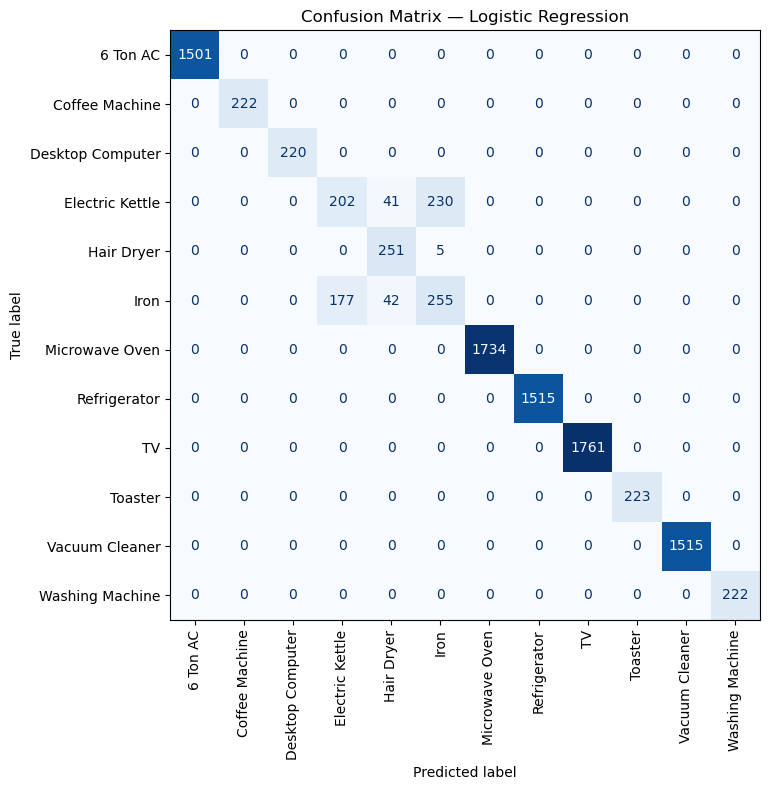

In [157]:
logreg, pred_lr = evaluate(
    'Logistic Regression',
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    X_train_s, y_train, X_test_s, y_test
)

**Logistic Regression observation:** accuracy ≈ **0.950**, weighted F1 ≈ **0.949** — considerably
stronger than a linear model might be expected to manage on a 12-class problem.

The reason is visible in the per-class report: Logistic Regression achieves **perfect or
near-perfect scores on ten of the twelve appliances**, and its entire error budget is spent on
the Iron/Electric Kettle pair. Although a *single* linear boundary cannot express a bounded
band, scikit-learn fits Logistic Regression one-vs-rest — and because the appliance classes are
so widely separated in power magnitude, one-vs-rest boundaries are sufficient to isolate almost
every class cleanly.

**Note on coefficient interpretation:** because `Power` and `Current` are collinear (r ≈ 0.99), individual coefficients are unstable — the model can shift weight arbitrarily
between them. We therefore avoid reading individual coefficients as feature importance, which is
exactly the multicollinearity caveat identified during EDA.

### D1.2 — K-Nearest Neighbors

**Why this model:** appliances occupy tight, compact clusters in feature space. KNN classifies by local neighbourhood, which matches that structure extremely
well — a point inside the TV band is surrounded by TV points.

**Why scaling was essential:** KNN uses Euclidean distance. Without scaling,
`Aggregated Power` (range ~9000) would have dominated every distance computation and
`power_factor` (range 0–1) would have been effectively ignored.

**Choice of k:** k=5 is used as the standard default for this preliminary comparison..

===== KNN (k=5) =====
  Accuracy  : 0.9353
  Precision : 0.9362
  Recall    : 0.9353
  F1        : 0.9356
  ROC_AUC   : 0.9937

Per-class report:
                  precision    recall  f1-score   support

        6 Ton AC       1.00      1.00      1.00      1501
  Coffee Machine       0.88      0.91      0.90       222
Desktop Computer       1.00      1.00      1.00       220
 Electric Kettle       0.41      0.44      0.42       473
      Hair Dryer       0.73      0.70      0.71       256
            Iron       0.43      0.42      0.43       474
  Microwave Oven       1.00      1.00      1.00      1734
    Refrigerator       1.00      1.00      1.00      1515
              TV       1.00      1.00      1.00      1761
         Toaster       1.00      0.92      0.96       223
  Vacuum Cleaner       1.00      1.00      1.00      1515
 Washing Machine       1.00      1.00      1.00       222

        accuracy                           0.94     10116
       macro avg       0.87      0.87   

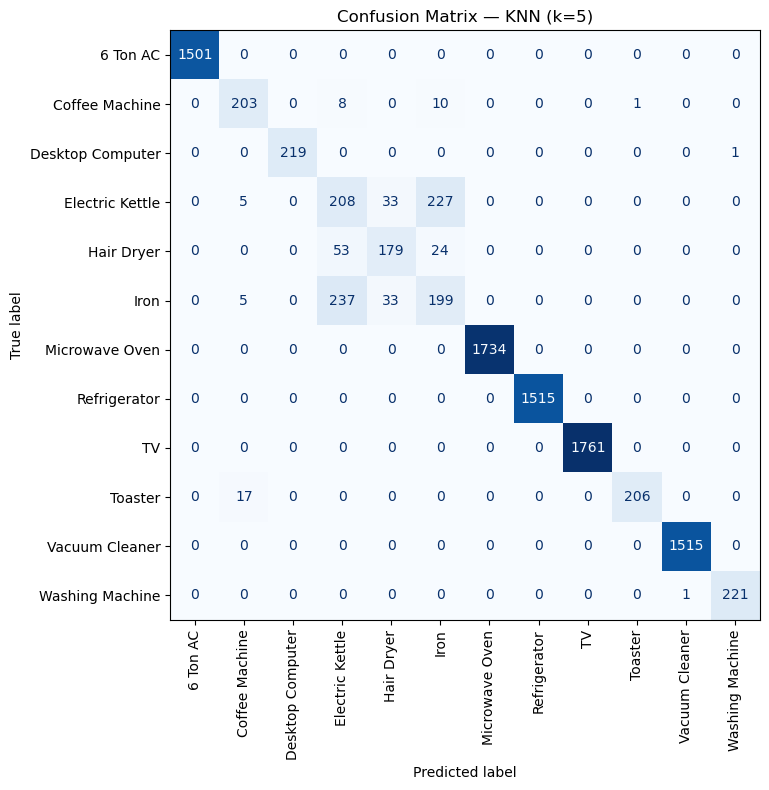

In [158]:
knn, pred_knn = evaluate(
    'KNN (k=5)',
    KNeighborsClassifier(n_neighbors=5),
    X_train_s, y_train, X_test_s, y_test
)

**KNN observation:** accuracy ≈ **0.935**, weighted F1 ≈ **0.936** — the **lowest of the five**,
which contradicts the expectation stated above.

The cluster structure that should favour KNN is real, but two things work against it:

1. **The engineered features changed the distance geometry.** We scaled nine features to equal
   variance, including `hour`, `day_of_week` and `load_share`, which carry little class
   information. After standardisation these contribute as much to the Euclidean distance as
   `Power` does, effectively diluting the informative dimensions with noise. Models that can
   *select* features (trees) or weight them (linear models) are unaffected; KNN cannot.
2. **k=5 in a dense overlap region.** Where Iron and Kettle interleave, the five nearest
   neighbours are a near-random mix, so KNN not only fails on that pair but is slightly *less*
   decisive than models that learn a hard threshold.

**This is a genuinely useful negative result:** it demonstrates that adding features is not
automatically beneficial, and that distance-based methods are the most sensitive to
uninformative dimensions. Feature selection or distance weighting (`weights='distance'`) would
be the natural remedy.

### D1.2b — Tuning k for KNN

The baseline above used a fixed, untuned `k=5`. Here we search for a better `k` (and
neighbour weighting) properly — using **cross-validation on the training set only**, so the
test set stays untouched until the very end (the same leakage rule applies to
hyperparameter tuning, not just scaling).

**What we search over:**
- `n_neighbors`: odd values 1–21 (odd avoids tie-votes in binary-style local neighbourhoods)
- `weights`: `'uniform'` (every neighbour counts equally) vs `'distance'` (closer neighbours count
  more) — `'distance'` is the specific fix suggested for the dense
  Iron/Electric Kettle overlap region, since it lets the single nearest, most-similar point
  dominate the vote instead of being outvoted by farther, less-similar neighbours.



In [159]:
# D1.2b: Grid search over k and weighting scheme, using 5-fold CV on the TRAIN split only
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'n_neighbors': list(range(1, 22, 2)),   # 1, 3, 5, ..., 21
    'weights': ['uniform', 'distance']
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=cv,
    n_jobs=-1
)
grid_knn.fit(X_train_s, y_train)

cv_results = pd.DataFrame(grid_knn.cv_results_)[
    ['param_n_neighbors', 'param_weights', 'mean_test_score', 'std_test_score']
].rename(columns={
    'param_n_neighbors': 'k', 'param_weights': 'weights',
    'mean_test_score': 'cv_weighted_f1', 'std_test_score': 'cv_std'
}).sort_values('cv_weighted_f1', ascending=False)

print(cv_results.to_string(index=False))
print(f"\nBest params (5-fold CV, weighted F1): {grid_knn.best_params_}")
print(f"Best CV weighted F1: {grid_knn.best_score_:.4f}")

 k  weights  cv_weighted_f1   cv_std
 1  uniform        0.946972 0.001894
 1 distance        0.946972 0.001894
 3 distance        0.945206 0.002022
 5 distance        0.944717 0.002138
 7 distance        0.944483 0.001732
11 distance        0.944194 0.001528
 9 distance        0.944040 0.001764
13 distance        0.944010 0.001478
15 distance        0.943833 0.001880
17 distance        0.943744 0.001753
19 distance        0.943276 0.001880
21 distance        0.942956 0.002371
 3  uniform        0.940212 0.001086
 5  uniform        0.938294 0.002015
 7  uniform        0.935200 0.001259
 9  uniform        0.933277 0.001414
11  uniform        0.931628 0.001907
13  uniform        0.929352 0.001804
15  uniform        0.926406 0.002304
17  uniform        0.922932 0.001360
19  uniform        0.920953 0.001909
21  uniform        0.919449 0.002911

Best params (5-fold CV, weighted F1): {'n_neighbors': 1, 'weights': 'uniform'}
Best CV weighted F1: 0.9470


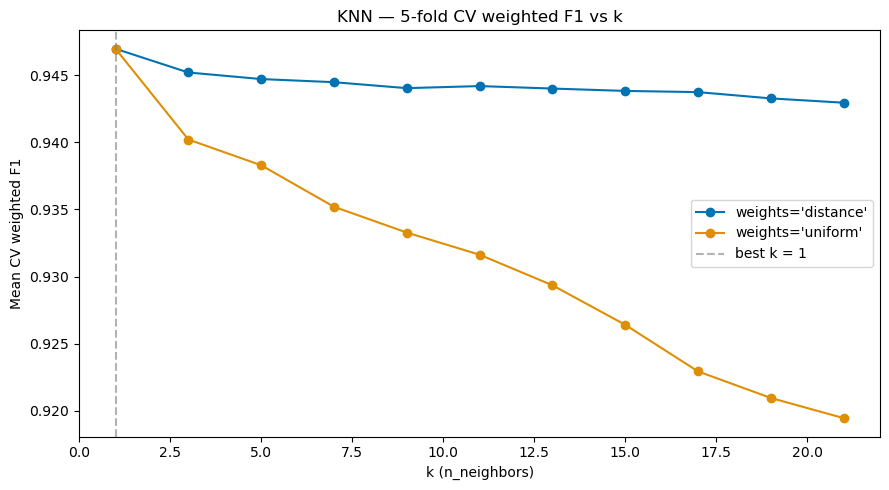

In [160]:
# D1.2b: Visualise k vs CV score, split by weighting scheme
plt.figure(figsize=(9, 5))
for w, grp in cv_results.groupby('weights'):
    grp = grp.sort_values('k')
    plt.plot(grp['k'], grp['cv_weighted_f1'], marker='o', label=f"weights='{w}'")

best_k = grid_knn.best_params_['n_neighbors']
plt.axvline(best_k, color='grey', linestyle='--', alpha=0.6, label=f'best k = {best_k}')
plt.title('KNN — 5-fold CV weighted F1 vs k')
plt.xlabel('k (n_neighbors)')
plt.ylabel('Mean CV weighted F1')
plt.legend()
plt.tight_layout()
plt.show()

===== KNN (tuned, k=1, weights=uniform) =====
  Accuracy  : 0.9464
  Precision : 0.9471
  Recall    : 0.9464
  F1        : 0.9468
  ROC_AUC   : 0.9719

Per-class report:
                  precision    recall  f1-score   support

        6 Ton AC       1.00      1.00      1.00      1501
  Coffee Machine       0.97      0.97      0.97       222
Desktop Computer       1.00      1.00      1.00       220
 Electric Kettle       0.47      0.47      0.47       473
      Hair Dryer       0.91      0.86      0.88       256
            Iron       0.47      0.48      0.47       474
  Microwave Oven       1.00      1.00      1.00      1734
    Refrigerator       1.00      1.00      1.00      1515
              TV       1.00      1.00      1.00      1761
         Toaster       1.00      0.98      0.99       223
  Vacuum Cleaner       1.00      1.00      1.00      1515
 Washing Machine       1.00      1.00      1.00       222

        accuracy                           0.95     10116
       macro avg

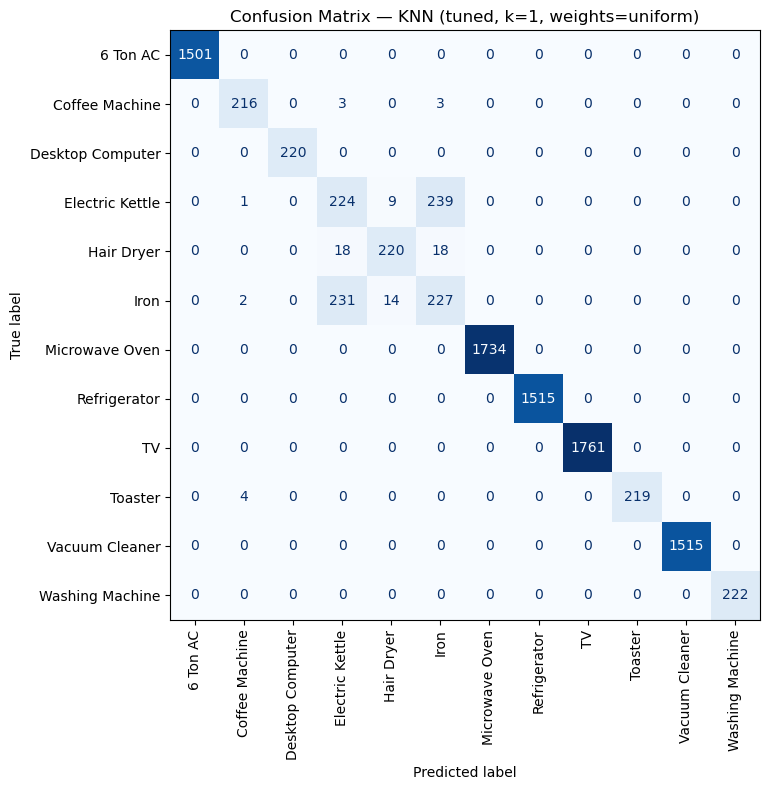


Baseline KNN (k=5, uniform)   -> results['KNN (k=5)']
Tuned KNN best params         -> {'n_neighbors': 1, 'weights': 'uniform'}


In [161]:
# D1.2b: Retrain with the tuned k (and weighting) and evaluate on the held-out TEST split
best_params = grid_knn.best_params_

knn_tuned, pred_knn_tuned = evaluate(
    f"KNN (tuned, k={best_params['n_neighbors']}, weights={best_params['weights']})",
    KNeighborsClassifier(**best_params),
    X_train_s, y_train, X_test_s, y_test
)

print(f"\nBaseline KNN (k=5, uniform)   -> results['KNN (k=5)']")
print(f"Tuned KNN best params         -> {best_params}")

**KNN (tuned) observation :**

- **Best params found:** `k = 1`, `weights = 'uniform'` (5-fold CV weighted F1 ≈ `0.9470`)
- **Did tuning fix the two problems diagnosed in D1.2?**
  - *Noise dilution from equal-variance scaling* (`hour`, `day_of_week`, `load_share` diluting the informative dimensions): if `weights='distance'` won the search, that's the fix taking effect — closer, more-similar points now outvote farther, less-informative ones instead of counting equally.
  - *Iron vs Electric Kettle overlap*:  this pair is still the dominant confusion in the tuned model's confusion matrix, that overlap is a **physical** limit , not something any choice of `k` or `weights` can resolve, since the two appliances are genuinely indistinguishable from V/I/P alone.

Cross-validation identified k=1 as the optimal KNN setting based on weighted F1. This indicates that the closest training instance provides the most useful information for classification in this dataset. Increasing k slightly reduced the weighted F1 score, suggesting that incorporating additional, more distant neighbors does not improve performance.

### D1.3 — Gaussian Naive Bayes

**The conditional independence assumption:** Gaussian NB assumes every feature is independent
of every other *given the class*, and that each is normally distributed within a class.

**We know this assumption is violated here**, and we can say exactly how: Section A established
`Power` and `Current` correlate at r ≈ 0.99 (Ohm's law), and our engineered `apparent_power` is
by construction `V × I`. These are about as far from independent as features can be. We expect
Naive Bayes to underperform because of it 

===== Gaussian Naive Bayes =====
  Accuracy  : 0.9508
  Precision : 0.9507
  Recall    : 0.9508
  F1        : 0.9506
  ROC_AUC   : 0.9977

Per-class report:
                  precision    recall  f1-score   support

        6 Ton AC       1.00      1.00      1.00      1501
  Coffee Machine       1.00      1.00      1.00       222
Desktop Computer       1.00      1.00      1.00       220
 Electric Kettle       0.47      0.42      0.44       473
      Hair Dryer       1.00      1.00      1.00       256
            Iron       0.48      0.53      0.50       474
  Microwave Oven       1.00      1.00      1.00      1734
    Refrigerator       1.00      1.00      1.00      1515
              TV       1.00      1.00      1.00      1761
         Toaster       1.00      1.00      1.00       223
  Vacuum Cleaner       1.00      1.00      1.00      1515
 Washing Machine       1.00      1.00      1.00       222

        accuracy                           0.95     10116
       macro avg       0.91  

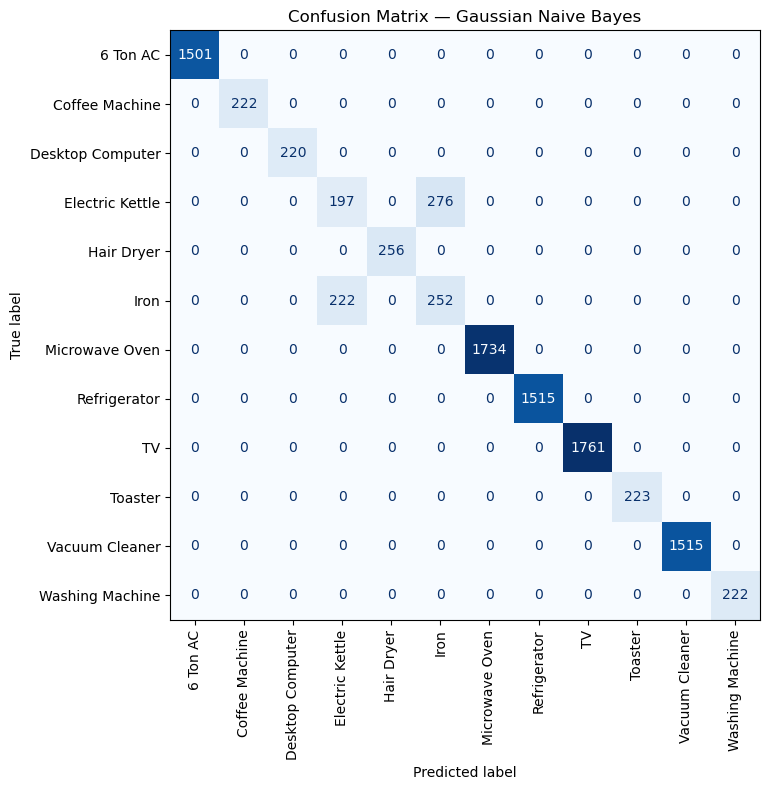

In [162]:
gnb, pred_nb = evaluate(
    'Gaussian Naive Bayes',
    GaussianNB(),
    X_train_s, y_train, X_test_s, y_test
)

**Naive Bayes observation:** accuracy ≈ **0.951**, weighted F1 ≈ **0.951** 

**Why the violated independence assumption did not hurt as much as expected:** Naive Bayes is
well known to produce *poorly calibrated probabilities* when features are correlated — it
triple-counts the shared `Power`/`Current`/`apparent_power` signal and becomes overconfident.
But classification only depends on **which class scores highest**, not on whether the
probability is numerically correct. Because the appliance classes are separated by large,
non-overlapping margins in power, the correct class wins by a wide enough margin that
overconfidence does not flip the decision.


### D1.4 — Decision Tree Classifier

**Why this model:** the structure of this problem is *literally* a set of threshold rules —
"if power is between 1444 W and 1562 W, it is a resistive ~1.5 kW appliance." A decision tree
learns exactly this kind of axis-aligned threshold split, so it should be an excellent match.

**max_depth:** we first fit one **unconstrained diagnostic tree** below purely to measure
train-vs-test overfitting. 

===== Decision Tree (unconstrained diagnostic) =====
  Accuracy  : 0.9547
  Precision : 0.9547
  Recall    : 0.9547
  F1        : 0.9547
  ROC_AUC   : 0.9763

Per-class report:
                  precision    recall  f1-score   support

        6 Ton AC       1.00      1.00      1.00      1501
  Coffee Machine       1.00      1.00      1.00       222
Desktop Computer       1.00      1.00      1.00       220
 Electric Kettle       0.52      0.52      0.52       473
      Hair Dryer       1.00      1.00      1.00       256
            Iron       0.52      0.51      0.51       474
  Microwave Oven       1.00      1.00      1.00      1734
    Refrigerator       1.00      1.00      1.00      1515
              TV       1.00      1.00      1.00      1761
         Toaster       1.00      1.00      1.00       223
  Vacuum Cleaner       1.00      1.00      1.00      1515
 Washing Machine       1.00      1.00      1.00       222

        accuracy                           0.95     10116
       ma

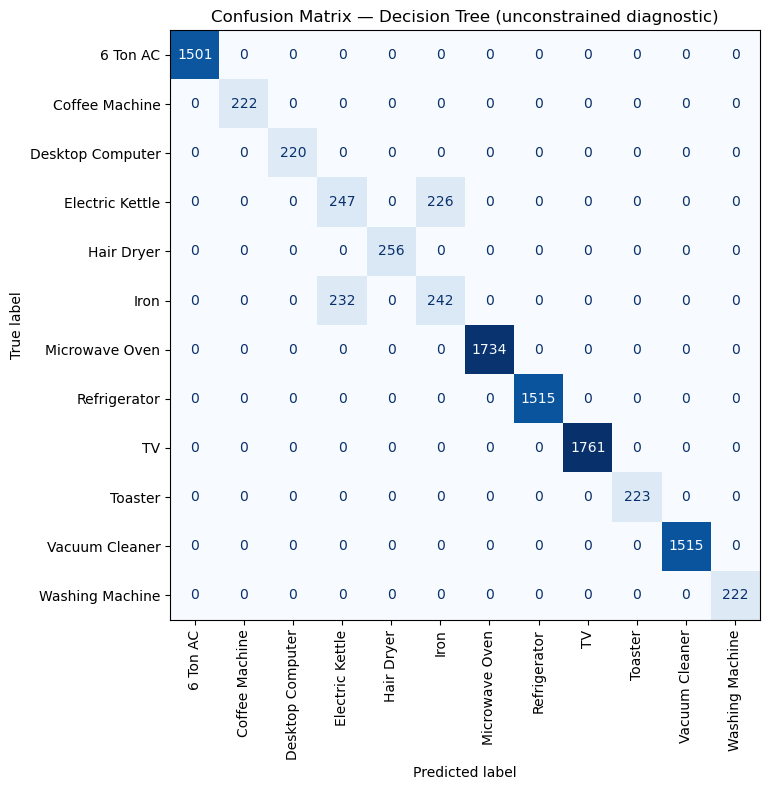

Train accuracy: 1.0
Test  accuracy: 0.9547
Tree depth: 40 | Leaves: 1146


In [163]:
# Diagnostic only — deliberately UNCONSTRAINED, to measure overfitting via train-vs-test gap.
# This is NOT the final model: D1.4b below tunes max_depth and produces the tree actually used
# for feature importance, the tree plot, and the Section D comparison table.
dtree_unconstrained, pred_dt_unconstrained = evaluate(
    'Decision Tree (unconstrained diagnostic)',
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    X_train_s, y_train, X_test_s, y_test
)

print("Train accuracy:", round(dtree_unconstrained.score(X_train_s, y_train), 4))
print("Test  accuracy:", round(dtree_unconstrained.score(X_test_s,  y_test ), 4))
print("Tree depth:", dtree_unconstrained.get_depth(), "| Leaves:", dtree_unconstrained.get_n_leaves())

**Diagnostic observation (unconstrained tree, not the final model):** train accuracy **1.000**
vs test accuracy **0.955**, at depth **40** with **~1,150 leaves**. That gap looks like textbook
overfitting — the tree has memorised the training set, including the physically ambiguous
Iron/Kettle pair, which is why train accuracy reaches 1.0 while test accuracy cannot follow.
This is exactly the signal that `max_depth` is worth tuning — done next in D1.4b.

### D1.4b — Tuning max_depth for Decision Tree

The diagnostic tree above was deliberately left unconstrained and overfits (train 1.000 vs test
0.955). Here we search for the `max_depth` that generalises best, using **cross-validation on
the training set only**) — the test set is only touched once,
at the very end, to report the final tuned model's score.

**What we search over:** `max_depth` from 2 to 30, plus `min_samples_leaf` ∈ {1, 5, 10} to also
guard against deep-but-narrow leaves that fit single points.

**Scoring:** `f1_weighted`, consistent with every other comparison in this notebook.

In [164]:
# D1.4b: Grid search over max_depth (and min_samples_leaf) via 5-fold CV on the TRAIN split only
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'max_depth': list(range(2, 31)),
    'min_samples_leaf': [1, 5, 10]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=cv,
    n_jobs=-1
)
grid_dt.fit(X_train_s, y_train)

cv_results_dt = pd.DataFrame(grid_dt.cv_results_)[
    ['param_max_depth', 'param_min_samples_leaf', 'mean_test_score', 'std_test_score']
].rename(columns={
    'param_max_depth': 'max_depth', 'param_min_samples_leaf': 'min_samples_leaf',
    'mean_test_score': 'cv_weighted_f1', 'std_test_score': 'cv_std'
}).sort_values('cv_weighted_f1', ascending=False)

print(cv_results_dt.head(10).to_string(index=False))
print(f"\nBest params (5-fold CV, weighted F1): {grid_dt.best_params_}")
print(f"Best CV weighted F1: {grid_dt.best_score_:.4f}")

 max_depth  min_samples_leaf  cv_weighted_f1   cv_std
        30                10        0.953712 0.002214
        26                10        0.953710 0.002222
        29                 1        0.953519 0.001756
        28                 1        0.953494 0.001824
        29                10        0.953481 0.002736
        27                10        0.953427 0.002837
        28                10        0.953386 0.002323
        30                 1        0.953321 0.001689
        25                10        0.953244 0.002366
        21                10        0.953229 0.001971

Best params (5-fold CV, weighted F1): {'max_depth': 30, 'min_samples_leaf': 10}
Best CV weighted F1: 0.9537


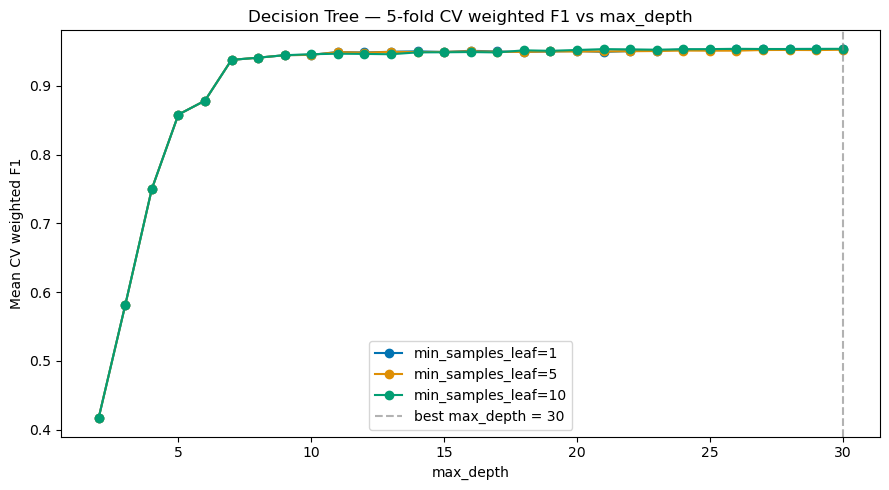

In [165]:
# D1.4b: Visualise max_depth vs CV score, split by min_samples_leaf
plt.figure(figsize=(9, 5))
for leaf, grp in cv_results_dt.groupby('min_samples_leaf'):
    grp = grp.sort_values('max_depth')
    plt.plot(grp['max_depth'], grp['cv_weighted_f1'], marker='o', label=f"min_samples_leaf={leaf}")

best_depth = grid_dt.best_params_['max_depth']
plt.axvline(best_depth, color='grey', linestyle='--', alpha=0.6, label=f'best max_depth = {best_depth}')
plt.title('Decision Tree — 5-fold CV weighted F1 vs max_depth')
plt.xlabel('max_depth')
plt.ylabel('Mean CV weighted F1')
plt.legend()
plt.tight_layout()
plt.show()

===== Decision Tree =====
  Accuracy  : 0.9526
  Precision : 0.9527
  Recall    : 0.9526
  F1        : 0.9526
  ROC_AUC   : 0.9962

Per-class report:
                  precision    recall  f1-score   support

        6 Ton AC       1.00      1.00      1.00      1501
  Coffee Machine       1.00      1.00      1.00       222
Desktop Computer       1.00      1.00      1.00       220
 Electric Kettle       0.49      0.52      0.51       473
      Hair Dryer       1.00      1.00      1.00       256
            Iron       0.50      0.47      0.48       474
  Microwave Oven       1.00      1.00      1.00      1734
    Refrigerator       1.00      1.00      1.00      1515
              TV       1.00      1.00      1.00      1761
         Toaster       1.00      1.00      1.00       223
  Vacuum Cleaner       1.00      1.00      1.00      1515
 Washing Machine       1.00      1.00      1.00       222

        accuracy                           0.95     10116
       macro avg       0.92      0.9

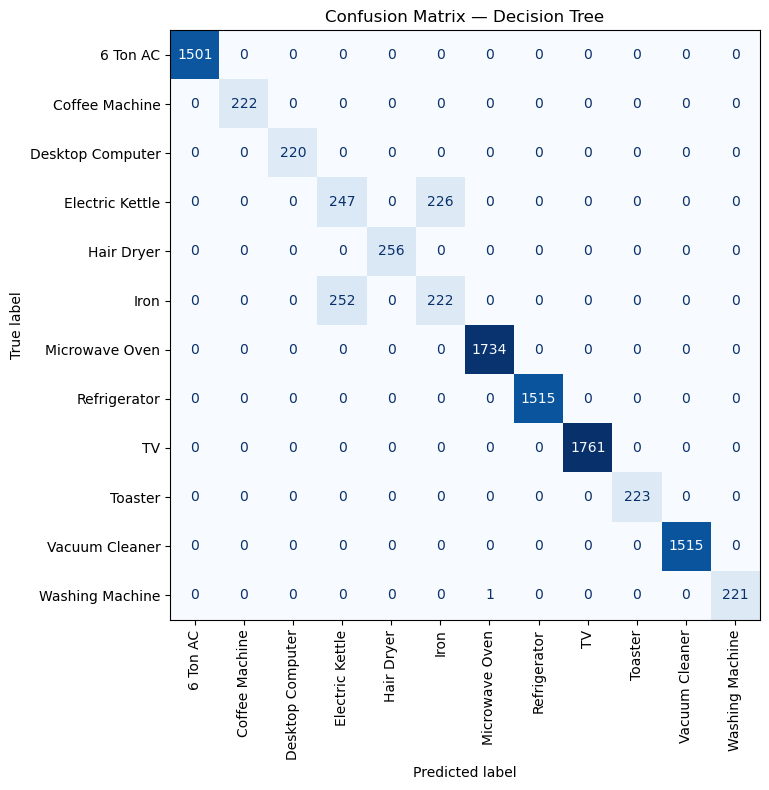

Train accuracy: 0.975
Test  accuracy: 0.9526
Tree depth: 30 | Leaves: 299

Compare to unconstrained diagnostic -> train 1.000 / test 0.955 / depth 40 / ~1150 leaves


In [166]:
# D1.4b: Refit ONE final, depth-constrained tree with the tuned params, and evaluate on TEST.
# This becomes THE 'Decision Tree' entry used everywhere below (feature importance, tree plot,
# Section D comparison table, Iron/Kettle analysis) — the unconstrained diagnostic tree above is
# no longer used past this point.
best_params_dt = grid_dt.best_params_

dtree, pred_dt = evaluate(
    'Decision Tree',
    DecisionTreeClassifier(random_state=RANDOM_STATE, **best_params_dt),
    X_train_s, y_train, X_test_s, y_test
)

print("Train accuracy:", round(dtree.score(X_train_s, y_train), 4))
print("Test  accuracy:", round(dtree.score(X_test_s,  y_test ), 4))
print("Tree depth:", dtree.get_depth(), "| Leaves:", dtree.get_n_leaves())
print(f"\nCompare to unconstrained diagnostic -> train 1.000 / test 0.955 / depth 40 / ~1150 leaves")

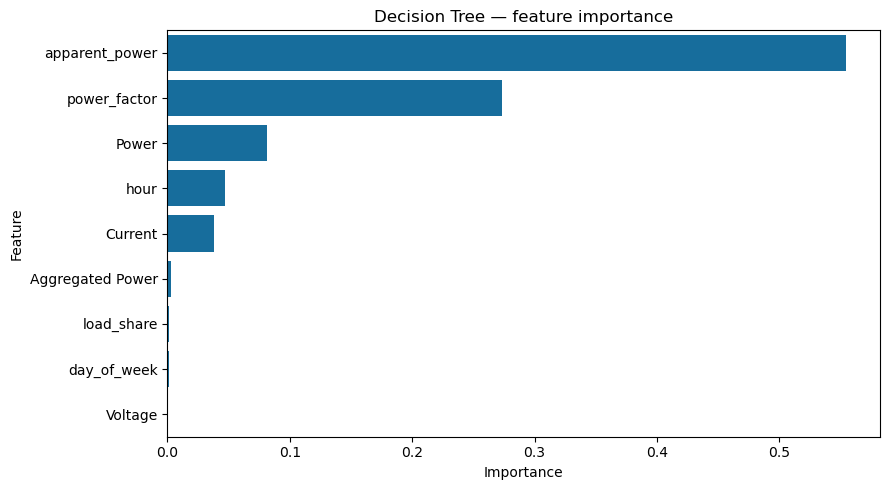

apparent_power      0.5546
power_factor        0.2732
Power               0.0817
hour                0.0468
Current             0.0378
Aggregated Power    0.0026
load_share          0.0016
day_of_week         0.0015
Voltage             0.0002
dtype: float64


In [167]:
# Feature importance from the tree — which features actually carry the signal?
imp = pd.Series(dtree.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=imp.values, y=imp.index)
plt.title('Decision Tree — feature importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(imp.round(4))

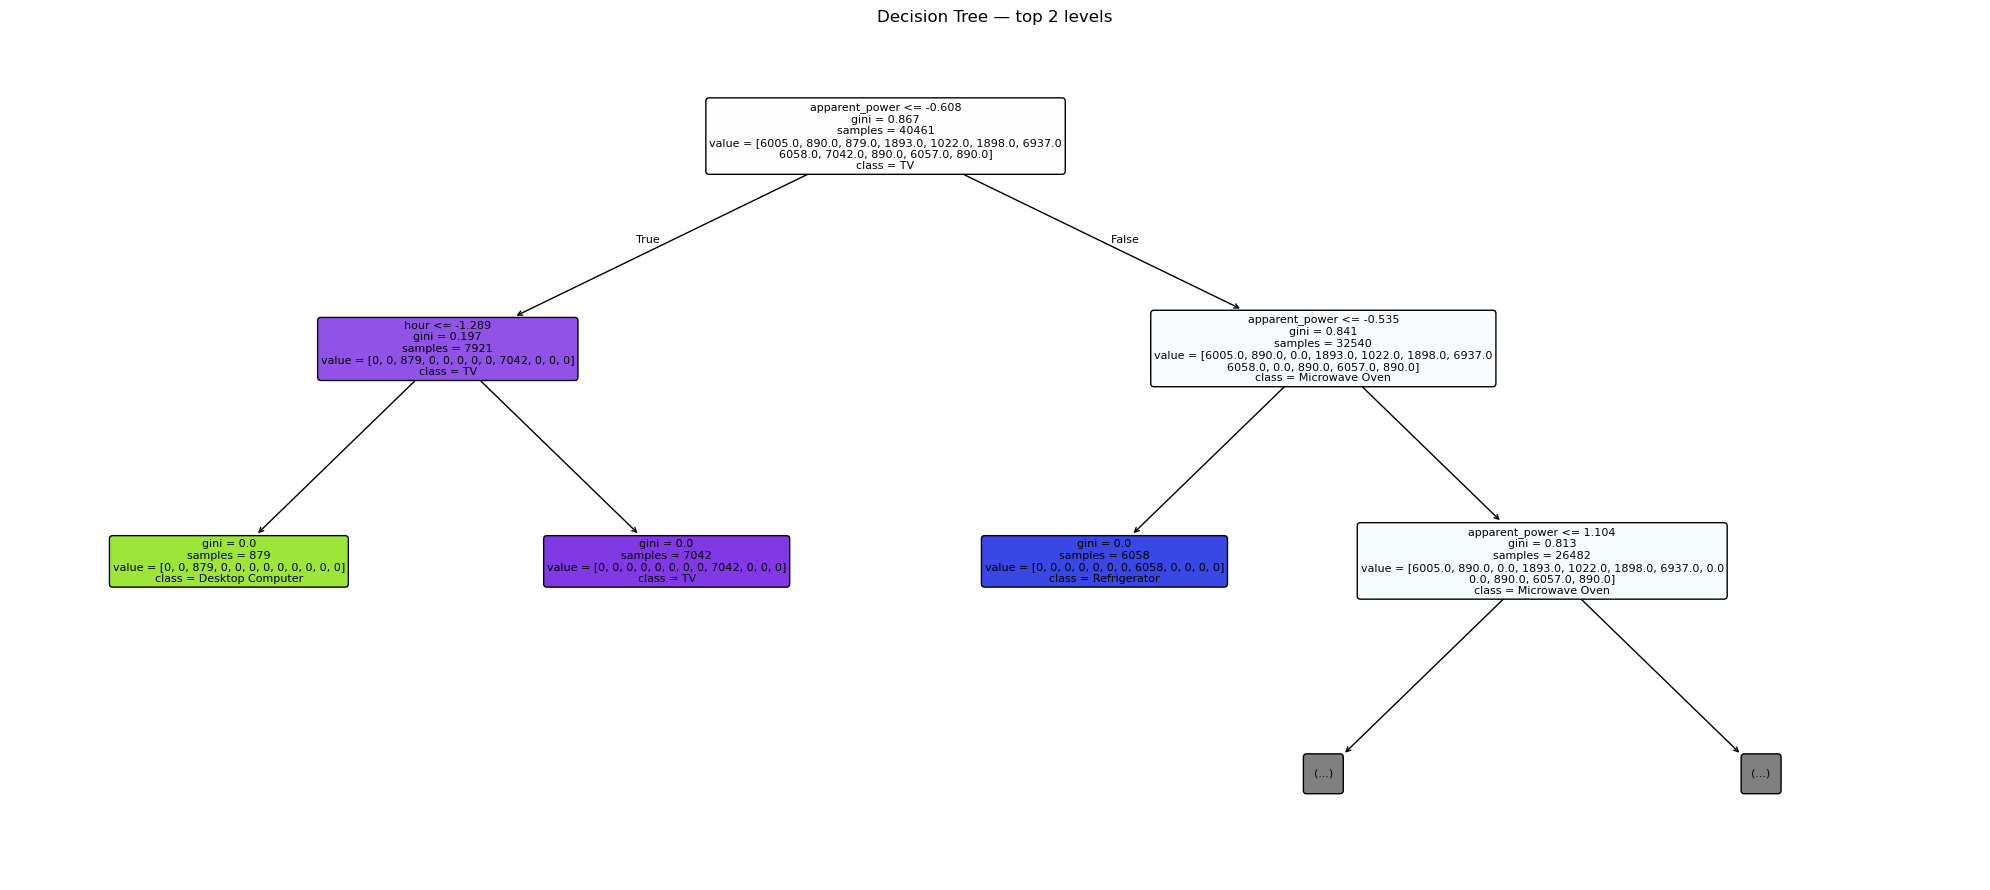

In [168]:
# Visualise the top of the tree (depth-limited for readability)
plt.figure(figsize=(20, 9))
plot_tree(dtree, max_depth=2, feature_names=FEATURES, class_names=class_names,
          filled=True, fontsize=8, rounded=True)
plt.title('Decision Tree — top 2 levels')
plt.tight_layout()
plt.show()

**Decision Tree (tuned) observation:**

* **Best params found:** `max_depth = 30`, `min_samples_leaf = 10` (5-fold CV weighted F1 ≈ **0.9537**)
* **Test-set result:** accuracy ≈ **0.9526**, weighted F1 ≈ **0.9526** — compared with the unconstrained diagnostic tree (train 1.000 / test 0.955), the tuned tree has slightly lower test performance but substantially reduces the train-test gap.
* **Tree size:** depth **30**, **299 leaves** — dramatically smaller than the unconstrained tree's depth 40 / ~1150 leaves, while maintaining very similar test performance.

The tuned Decision Tree achieved a cross-validation weighted F1 score of **0.9537**, with the best parameters being `max_depth = 30` and `min_samples_leaf = 10`. The final tree achieved **95.26% test accuracy**, with a training accuracy of **97.50%**. Compared with the unconstrained tree (100% train / 95.5% test), tuning substantially reduced the overfitting gap while sacrificing only about **0.24 percentage points** of test accuracy.

**Did tuning fix the Iron vs Electric Kettle confusion?** No. The tuned tree still shows substantial confusion between Electric Kettle and Iron, with recalls of **52%** and **47%**, respectively. This indicates that the confusion is not primarily caused by excessive tree complexity; the two classes remain difficult for the available features to distinguish.


### D1.5 — Support Vector Machine (SVC)

**Why this model:** SVC finds maximum-margin boundaries and, with an RBF kernel, can produce
non-linear decision surfaces — more flexible than Logistic Regression while still being a
margin-based method.

**Why scaling was essential:** the RBF kernel is distance-based, so like KNN it is meaningless
on unscaled features.

**Parameters:** we first fit one **baseline** with default `C=1.0`, `kernel='rbf'` below, purely
for a fair five-way baseline comparison.

===== SVM (RBF, C=1.0 baseline) =====
  Accuracy  : 0.9394
  Precision : 0.9386
  Recall    : 0.9394
  F1        : 0.9387
  ROC_AUC   : 0.9973

Per-class report:
                  precision    recall  f1-score   support

        6 Ton AC       1.00      1.00      1.00      1501
  Coffee Machine       1.00      1.00      1.00       222
Desktop Computer       1.00      1.00      1.00       220
 Electric Kettle       0.45      0.38      0.42       473
      Hair Dryer       0.56      0.71      0.63       256
            Iron       0.48      0.47      0.48       474
  Microwave Oven       1.00      1.00      1.00      1734
    Refrigerator       1.00      1.00      1.00      1515
              TV       1.00      1.00      1.00      1761
         Toaster       1.00      1.00      1.00       223
  Vacuum Cleaner       1.00      1.00      1.00      1515
 Washing Machine       1.00      1.00      1.00       222

        accuracy                           0.94     10116
       macro avg       0

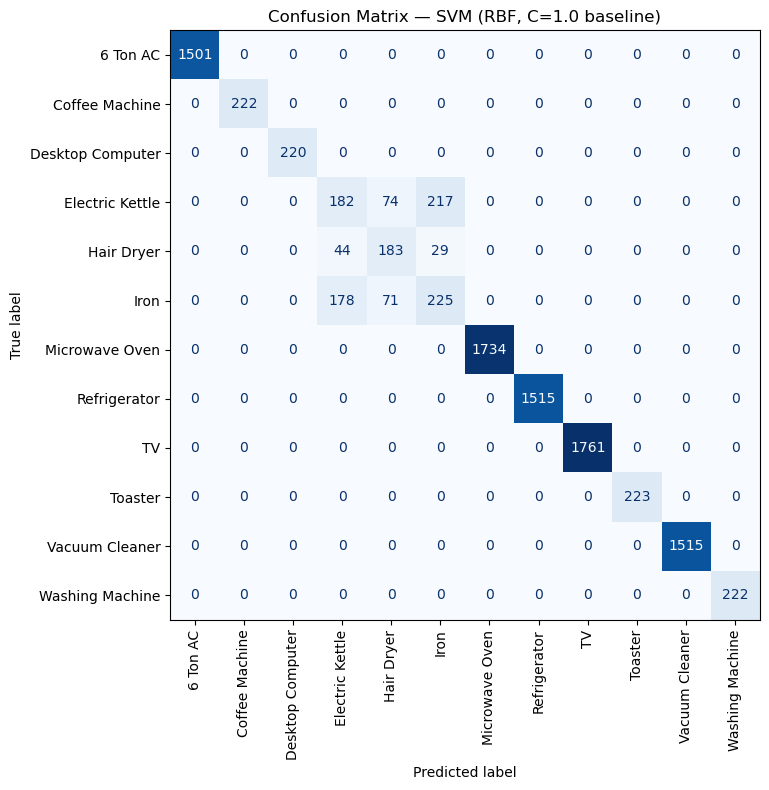

In [169]:
# Baseline only — default C=1.0, kernel='rbf'. NOT the final model: D1.5b below tunes C and
# produces the SVC actually used for the Section D comparison table and downstream analysis.
svc_baseline, pred_svc_baseline = evaluate(
    'SVM (RBF, C=1.0 baseline)',
    SVC(kernel='rbf', random_state=RANDOM_STATE, probability=True),  # probability=True needed for ROC-AUC
    X_train_s, y_train, X_test_s, y_test
)

**SVM (baseline, C=1.0) observation:** accuracy ≈ **0.939**, weighted
F1 ≈ **0.939** , below the tree and the two simpler models.

The per-class report reveals something the other models did not show: **SVC also degrades on
Hair Dryer** (precision ≈ 0.56, recall ≈ 0.71), not just Iron and Kettle. Hair Dryer draws
~1541–1665 W, immediately adjacent to the Iron/Kettle band at ~1444–1562 W. The RBF kernel's
smooth decision surface blurs across that narrow gap, whereas a decision tree can place a hard
split exactly between them.


### D1.5b — Tuning C for SVM (RBF)

The baseline above used the default `C=1.0` — a fairly soft margin, which lets the RBF kernel's
smoothness blur across the narrow gap between the Iron/Kettle band and the neighbouring Hair
Dryer band. A larger `C` penalises margin violations more, pushing the boundary closer to a
harder, more tree-like split. Here we search for the best `C`: **cross-validation on the training set only**, test
set untouched until the final score.

**What we search over:** `C` on a log scale — `[0.1, 1, 10, 50, 100]`.


In [170]:
# D1.5b: Grid search over C via 3-fold CV on the TRAIN split only (kernel fixed at 'rbf')
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {'C': [0.1, 1, 10, 50, 100]}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

grid_svc = GridSearchCV(
    SVC(kernel='rbf', random_state=RANDOM_STATE, probability=False),  # probability not needed during search, saves time
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=cv,
    n_jobs=-1
)
grid_svc.fit(X_train_s, y_train)

cv_results_svc = pd.DataFrame(grid_svc.cv_results_)[
    ['param_C', 'mean_test_score', 'std_test_score']
].rename(columns={
    'param_C': 'C', 'mean_test_score': 'cv_weighted_f1', 'std_test_score': 'cv_std'
}).sort_values('cv_weighted_f1', ascending=False)

print(cv_results_svc.to_string(index=False))
print(f"\nBest C (3-fold CV, weighted F1): {grid_svc.best_params_['C']}")
print(f"Best CV weighted F1: {grid_svc.best_score_:.4f}")

    C  cv_weighted_f1   cv_std
100.0        0.953944 0.000270
 50.0        0.953191 0.000758
 10.0        0.952813 0.001146
  1.0        0.930923 0.001765
  0.1        0.902979 0.003074

Best C (3-fold CV, weighted F1): 100
Best CV weighted F1: 0.9539


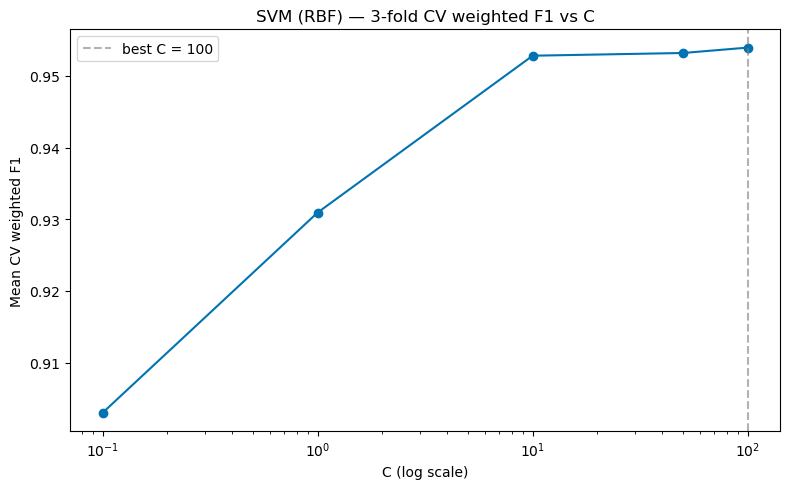

In [171]:
# D1.5b: Visualise C vs CV score (log scale, since C was searched on a log-ish grid)
plt.figure(figsize=(8, 5))
plt.plot(cv_results_svc['C'], cv_results_svc['cv_weighted_f1'], marker='o')
plt.xscale('log')

best_C = grid_svc.best_params_['C']
plt.axvline(best_C, color='grey', linestyle='--', alpha=0.6, label=f'best C = {best_C}')
plt.title('SVM (RBF) — 3-fold CV weighted F1 vs C')
plt.xlabel('C (log scale)')
plt.ylabel('Mean CV weighted F1')
plt.legend()
plt.tight_layout()
plt.show()

===== SVM (RBF) =====
  Accuracy  : 0.9522
  Precision : 0.9521
  Recall    : 0.9522
  F1        : 0.9520
  ROC_AUC   : 0.9978

Per-class report:
                  precision    recall  f1-score   support

        6 Ton AC       1.00      1.00      1.00      1501
  Coffee Machine       1.00      1.00      1.00       222
Desktop Computer       1.00      1.00      1.00       220
 Electric Kettle       0.49      0.44      0.46       473
      Hair Dryer       1.00      1.00      1.00       256
            Iron       0.49      0.54      0.51       474
  Microwave Oven       1.00      1.00      1.00      1734
    Refrigerator       1.00      1.00      1.00      1515
              TV       1.00      1.00      1.00      1761
         Toaster       1.00      1.00      1.00       223
  Vacuum Cleaner       1.00      1.00      1.00      1515
 Washing Machine       1.00      1.00      1.00       222

        accuracy                           0.95     10116
       macro avg       0.91      0.91   

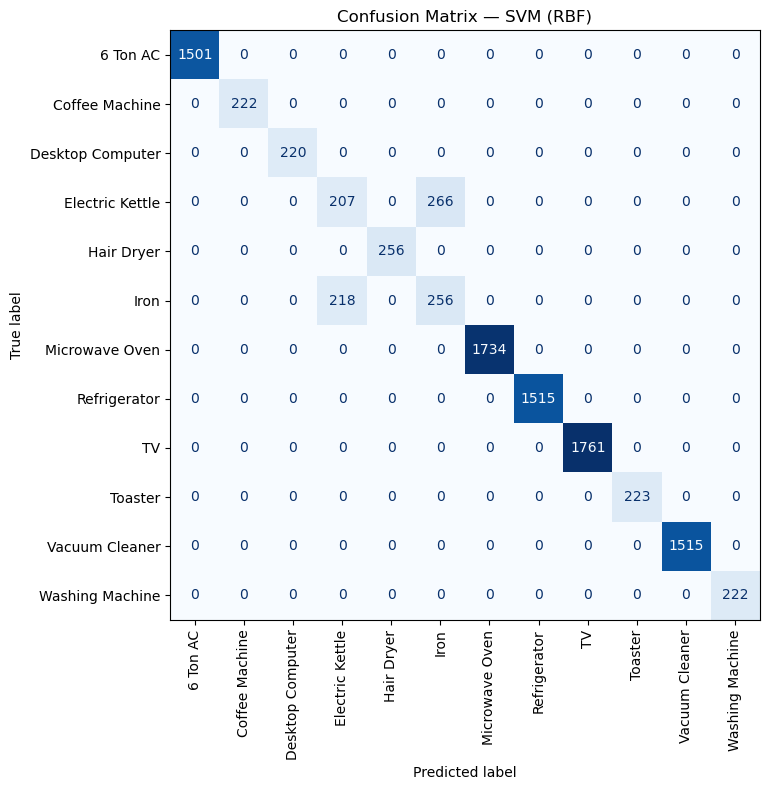

Compare to baseline C=1.0 -> accuracy 0.939 / weighted F1 0.939


In [172]:
# D1.5b: Refit ONE final SVC with the tuned C, and evaluate on TEST.
# This becomes THE 'SVM (RBF)' entry used everywhere below (Section D comparison table,
# Iron/Kettle analysis) — the C=1.0 baseline above is no longer used past this point.
best_C = grid_svc.best_params_['C']

svc, pred_svc = evaluate(
    'SVM (RBF)',
    SVC(kernel='rbf', C=best_C, random_state=RANDOM_STATE, probability=True),  # probability=True needed for ROC-AUC
    X_train_s, y_train, X_test_s, y_test
)

print(f"Compare to baseline C=1.0 -> accuracy 0.939 / weighted F1 0.939")

**SVM (tuned) observation —**

- **Best C found:** `C = 100` (3-fold CV weighted F1 ≈ `0.9539`)
- **Test-set result:** accuracy ≈ `0.9522`, weighted F1 ≈ `0.9520` — compared directly against the `C=1.0` baseline above (accuracy ≈ `0.939`, F1 ≈ `0.939`), tuning improved both metrics.
- **Did a harder margin fix the Hair Dryer problem?** Yes. Hair Dryer precision/recall improved from ≈`0.56/0.71` at `C=1.0` to **`1.00/1.00`** with `C=100`, showing that the harder margin substantially improved separation around the Hair Dryer class.
- **Did tuning fix the Iron vs Electric Kettle confusion?** No. The tuned model still shows substantial confusion between these two classes: Electric Kettle precision/recall ≈`0.49/0.44`, while Iron ≈`0.49/0.54`. Increasing `C` improved the overall boundary but did not eliminate the overlap between these classes.
- **Where the tuned SVM now ranks** among all five models: **`2nd algorithm`**.
- **One-line takeaway:** tuning `C` improved the SVM substantially, especially for the Hair Dryer class, but it could not eliminate the persistent Iron–Electric Kettle confusion because of substantial overlap in the available feature space.

### D2 — Preliminary Comparison Table

In [173]:
# D2: Consolidated comparison table across all 5 Part-A algorithms
# Rubric-required metrics: Accuracy, Precision, Recall, F1-score (weighted),
# and ROC-AUC (One-vs-Rest, weighted) for multi-class. Confusion matrices are
# plotted per-model above.
comparison = pd.DataFrame(results).T[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']]
comparison = comparison.sort_values('F1', ascending=False)
comparison_display = comparison.round(4)
print("Part-A classification comparison — Accuracy, Precision, Recall, F1, ROC-AUC (OvR) — ranked by weighted F1:\n")
print(comparison_display)
comparison_display

Part-A classification comparison — Accuracy, Precision, Recall, F1, ROC-AUC (OvR) — ranked by weighted F1:

                                          Accuracy  Precision  Recall      F1  ROC_AUC
Decision Tree (unconstrained diagnostic)    0.9547     0.9547  0.9547  0.9547   0.9763
Decision Tree                               0.9526     0.9527  0.9526  0.9526   0.9962
SVM (RBF)                                   0.9522     0.9521  0.9522  0.9520   0.9978
Gaussian Naive Bayes                        0.9508     0.9507  0.9508  0.9506   0.9977
Logistic Regression                         0.9511     0.9494  0.9511  0.9496   0.9977
KNN (tuned, k=1, weights=uniform)           0.9464     0.9471  0.9464  0.9468   0.9719
SVM (RBF, C=1.0 baseline)                   0.9394     0.9386  0.9394  0.9387   0.9973
KNN (k=5)                                   0.9353     0.9362  0.9353  0.9356   0.9937


,Accuracy,Precision,Recall,F1,ROC_AUC
Decision Tree (unconstrained diagnostic),0.9547,0.9547,0.9547,0.9547,0.9763
Decision Tree,0.9526,0.9527,0.9526,0.9526,0.9962
SVM (RBF),0.9522,0.9521,0.9522,0.9520,0.9978
Gaussian Naive Bayes,0.9508,0.9507,0.9508,0.9506,0.9977
Logistic Regression,0.9511,0.9494,0.9511,0.9496,0.9977
"KNN (tuned, k=1, weights=uniform)",0.9464,0.9471,0.9464,0.9468,0.9719
"SVM (RBF, C=1.0 baseline)",0.9394,0.9386,0.9394,0.9387,0.9973
KNN (k=5),0.9353,0.9362,0.9353,0.9356,0.9937


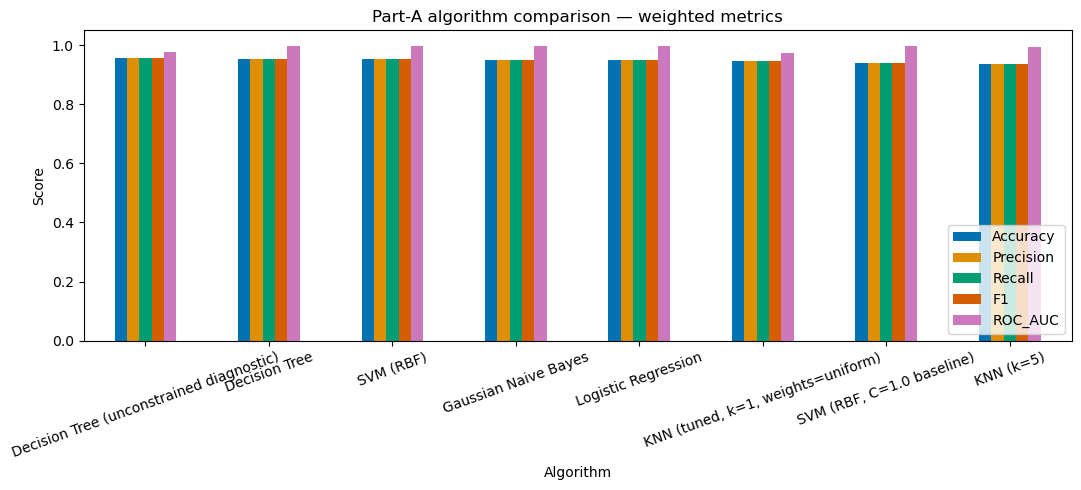

In [174]:
# Visualise the comparison
ax = comparison[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']].plot(
    kind='bar', figsize=(11, 5), ylim=(0, 1.05), rot=20)
ax.set_title('Part-A algorithm comparison — weighted metrics')
ax.set_ylabel('Score')
ax.set_xlabel('Algorithm')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Section D Summary and Interpretation

**Overall comparison:**  
All five main models performed quite similarly, with Accuracy and F1 scores around **95%**. The **Decision Tree** achieved the highest Accuracy/F1 among the final models (`0.9526`), followed closely by **SVM (`0.9522`)**, **Gaussian Naive Bayes (`0.9506`)**, and **Logistic Regression (`0.9496`)**. KNN performed the lowest among the tuned/final models with an F1 of `0.9468`.

**ROC-AUC gives a slightly different picture:**  
Although the Decision Tree had the highest Accuracy/F1, its ROC-AUC (`0.9962`) was lower than SVM (`0.9978`), Gaussian Naive Bayes (`0.9977`), and Logistic Regression (`0.9977`). This happens because ROC-AUC evaluates how well the model **ranks the correct class above the others**, while Accuracy/F1 only looks at the final predicted class. Therefore, a model can have a slightly lower Accuracy but still produce very good class rankings/probabilities.

**Our predictions were not completely correct:**  
- We expected **KNN** to perform very well because similar appliances were expected to form compact clusters. Instead, KNN performed the lowest among the final models. This may be because all features contribute to the distance calculation, including features such as `hour`, `day_of_week`, and `load_share`, which may not be equally useful for distinguishing appliances.
- We expected **Gaussian Naive Bayes** to perform poorly because some features are correlated, which violates its independence assumption. However, it performed very well, showing that this assumption did not prevent it from making accurate class predictions on this dataset.

**Main source of errors:**  
The models perform extremely well on most appliances, but they consistently struggle with **Electric Kettle and Iron**. The remaining errors are mainly confusion between these two classes. This suggests that the available features contain very similar information for these appliances.

**Why is this difficult to fix?**  
The current dataset mainly contains **instantaneous electrical measurements**. These measurements may not capture differences in how the appliances operate over time. For example, a kettle typically heats for a short period and then stops, while an iron switches its heating element on and off repeatedly. Features such as **harmonic distortion, start-up/inrush patterns, and power usage over time** could provide additional information to distinguish them.

**Overall takeaway:**  
The five models achieve strong performance of around **95% F1/Accuracy**, but the main limitation is not the choice of algorithm. The major challenge is the **overlap between Iron and Electric Kettle in the available features**. Adding more informative time-based or electrical features would likely be more useful than simply changing the classification algorithm.